# Lecture 1: Introduction to Machine Learning
### Hands-on walkthrough with the Breast Cancer Wisconsin Dataset

---

## What we will cover

| Section | Topic |
|---|---|
| 1 | What is Machine Learning? |
| 2 | Load and Explore a Dataset |
| 3 | Preprocess and Split the Data |
| 4 | Baseline Model with scikit-learn |
| 5 | Build and Train a Neural Network in PyTorch |
| 6 | Evaluate and Visualise Results |
| 7 | Bonus: Demonstrating Overfitting |

---

## 1. What is Machine Learning?

In **traditional programming** we write explicit rules:

![Traditional Programming Paradigm](./images/trad_prg.png)

In **machine learning** we let the computer learn the rules from examples:

![Machine Learning Paradigm](./images/ml_prg.png)

### The Core ML Loop

    [Data] -> [Model] -> [Prediction] -> [Loss] -> [Optimizer] -> (update weights) ->

1. **Data**: labelled examples (features + ground truth labels)
2. **Model**: a function with learnable parameters (weights)
3. **Loss**: how wrong are our predictions? A number we want to minimise.
4. **Optimizer**: nudges weights in the direction that reduces loss (gradient descent)
5. **Repeat** until the model generalises well to unseen data

### Key vocabulary
- **Feature**: a measurable input variable (e.g. cell radius, texture)
- **Label**: what we are trying to predict (e.g. malignant / benign)
- **Training set**: data the model learns from
- **Validation set**: used during training to tune hyperparameters
- **Test set**: held out completely; only touched once at the very end
- **Overfitting**: model memorises training data but fails on new data
- **Generalisation**: how well the model performs on unseen data

---

In [1]:
# All libraries below are pre-installed on Google Colab
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# scikit-learn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve,
    confusion_matrix, classification_report
)

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

print(f'PyTorch version : {torch.__version__}')
print(f"Running on      : {'GPU' if torch.cuda.is_available() else 'CPU'}")

PyTorch version : 2.6.0+cu124
Running on      : GPU


---
## 2. Load and Explore the Dataset

We will use the **Breast Cancer Wisconsin (Diagnostic)** dataset.

- **569 patient samples**
- **30 features** from digitised FNA biopsy images: radius, texture, perimeter, area, smoothness...
- **Binary label**: 0 = Malignant, 1 = Benign

> The goal is to classify tumours based on cell nucleus measurements.

In [4]:
raw = load_breast_cancer()

df = pd.DataFrame(raw.data, columns=raw.feature_names)
df['label']     = raw.target
df['diagnosis'] = df['label'].map({0: 'Malignant', 1: 'Benign'})

print(f'Dataset shape : {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}') # two .sum() ops because the first retunrs per feature statistics
print('\nClass balance:')
print(df['diagnosis'].value_counts())
df.head()

Dataset shape : (569, 32)
Missing values: 0

Class balance:
diagnosis
Benign       357
Malignant    212
Name: count, dtype: int64


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,label,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,Malignant


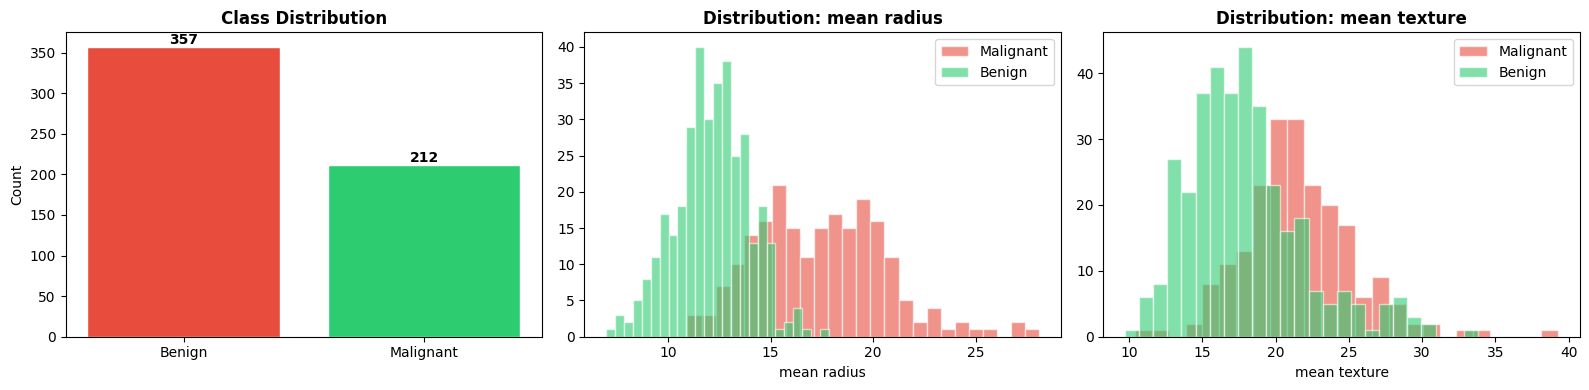

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Class distribution
counts = df['diagnosis'].value_counts()
axes[0].bar(counts.index, counts.values, color=['#e74c3c', '#2ecc71'], edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

# Feature histograms
for ax, feat in [(axes[1], 'mean radius'), (axes[2], 'mean texture')]:
    for diag, color in [('Malignant', '#e74c3c'), ('Benign', '#2ecc71')]:
        ax.hist(df[df['diagnosis']==diag][feat], bins=25, alpha=0.6,
                color=color, label=diag, edgecolor='white')
    ax.set_title(f'Distribution: {feat}', fontweight='bold')
    ax.set_xlabel(feat)
    ax.legend()

plt.tight_layout()
plt.show()

> Dealing with class imbalance : What would happen if the classifier learns to only predict one class all the time. Then we would have a system that achieved 62.74 % accuracy if it always predicted the **benign** label.

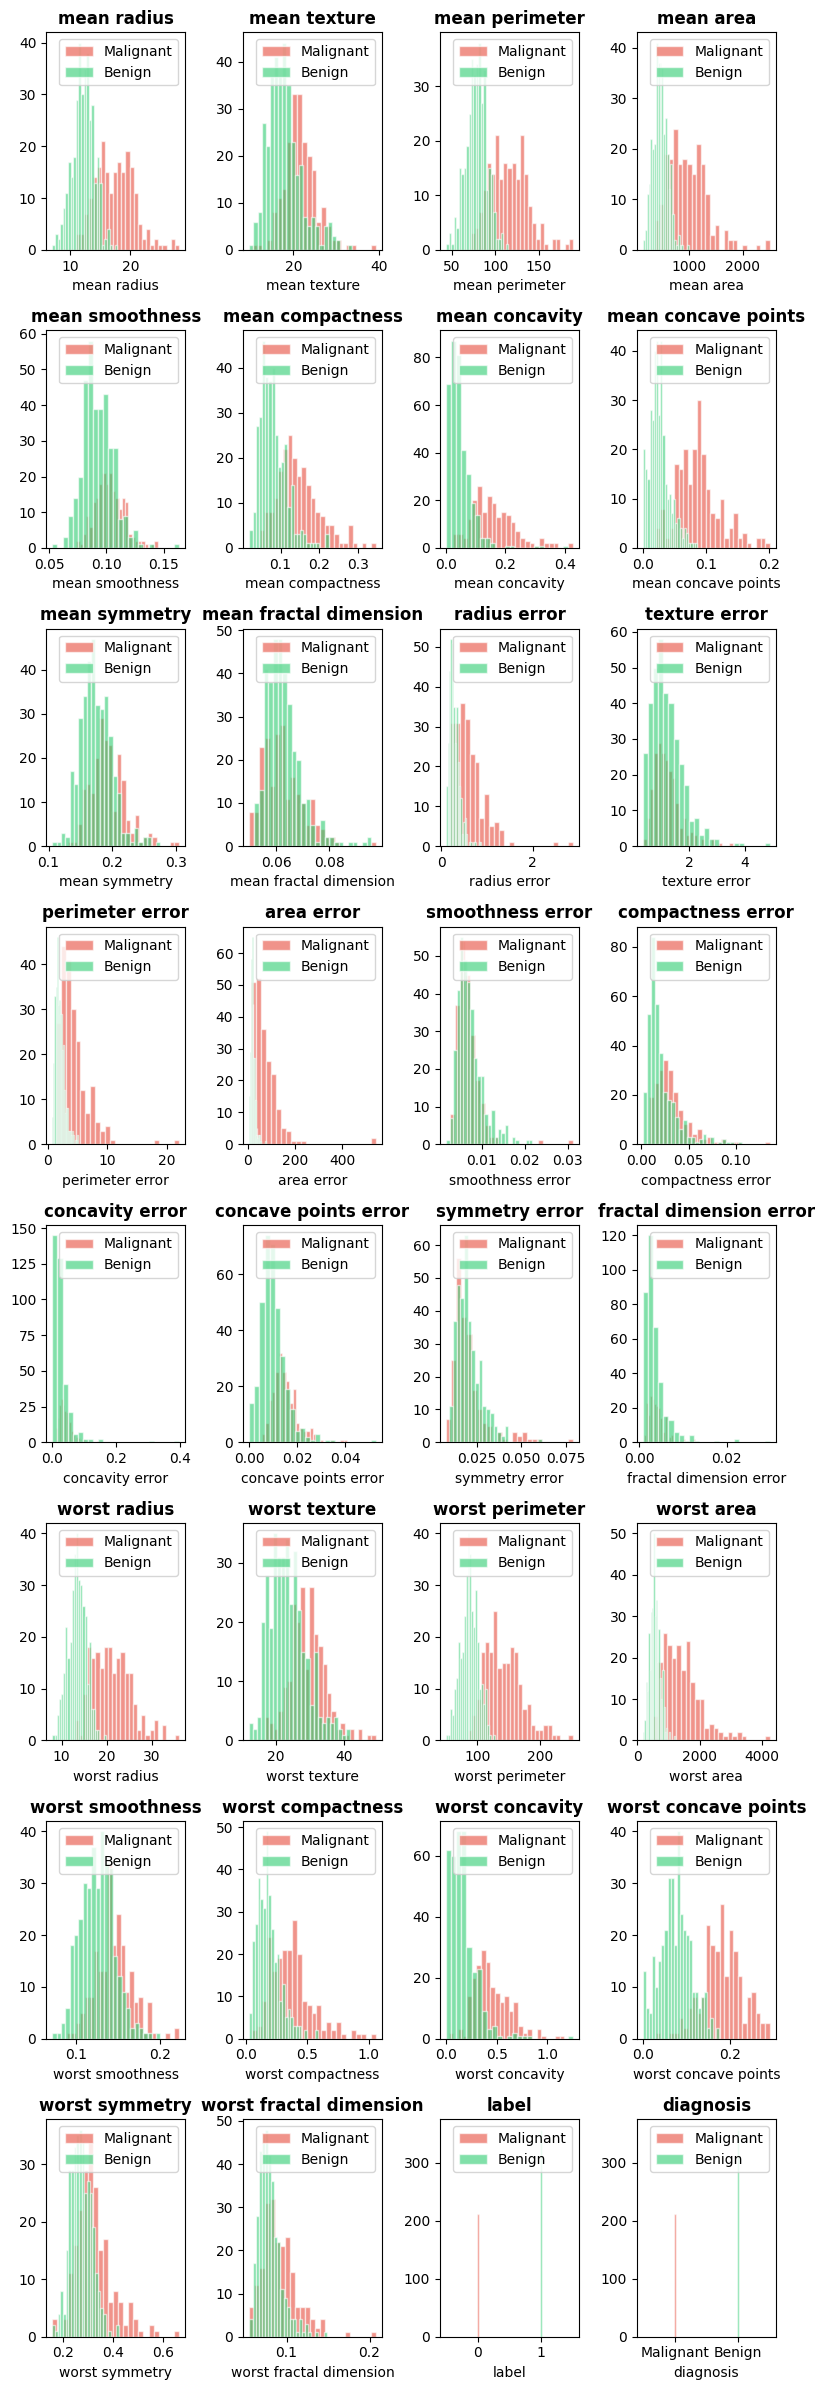

In [18]:
n_rows = 8
n_cols = 4
fig, axes = plt.subplots(n_rows, n_cols, figsize=(8,24))

# Feature histograms
for i, feat in enumerate(df.columns.tolist()):
    row = i // n_cols
    col = i % n_cols
    ax = axes[row][col]

    for diag, color in [('Malignant', '#e74c3c'), ('Benign', '#2ecc71')]:
        ax.hist(df[df['diagnosis']==diag][feat], bins=25, alpha=0.6,
                color=color, label=diag, edgecolor='white')
    ax.set_title(f'{feat}', fontweight='bold')
    ax.set_xlabel(feat)
    ax.legend()

plt.tight_layout()
plt.show()

> But but but! Is my data correlated?

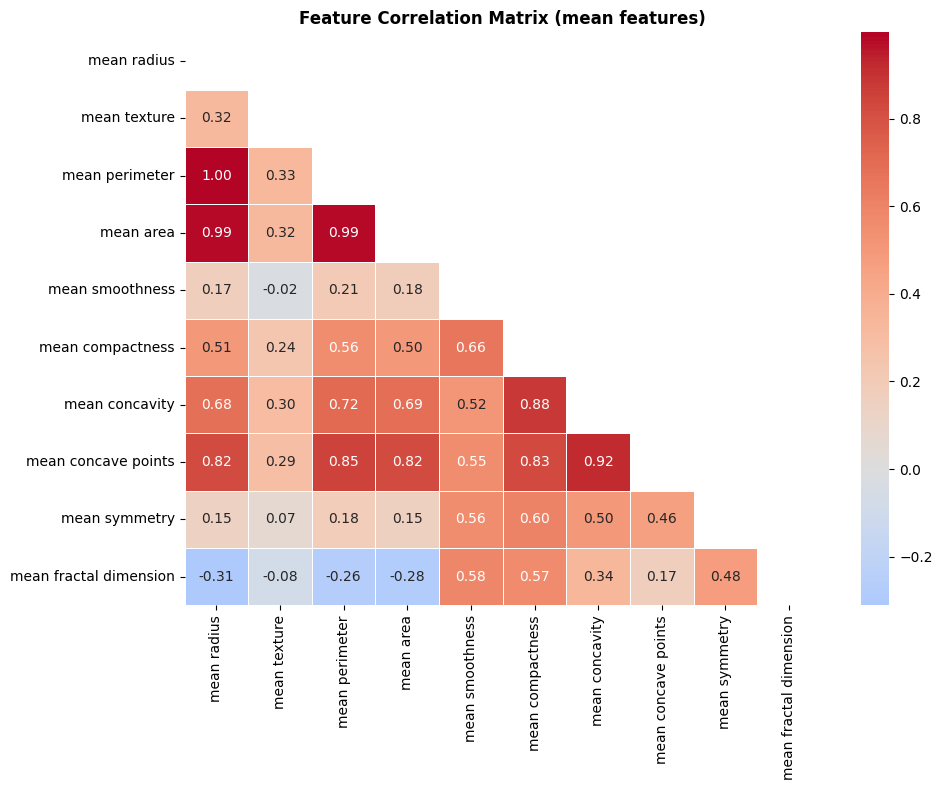

High correlations (e.g. radius & perimeter) mean some features carry redundant information.


In [22]:
mean_cols = [c for c in raw.feature_names if 'mean' in c]
corr = df[mean_cols].corr()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix (mean features)', fontweight='bold')
plt.tight_layout()
plt.show()
print('High correlations (e.g. radius & perimeter) mean some features carry redundant information.')

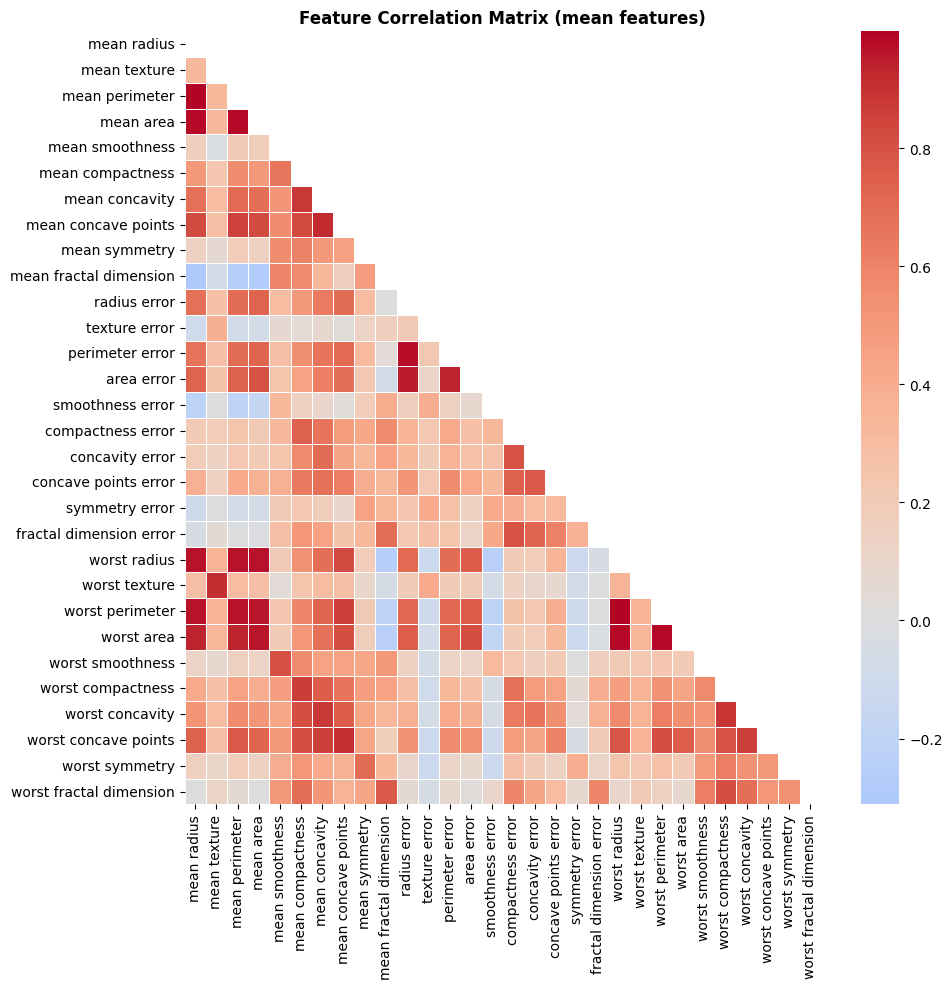

In [ ]:
all_cols = [c for c in raw.feature_names]
corr = df[all_cols].corr()

plt.figure(figsize=(10, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=False, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5)
plt.title('Feature Correlation Matrix (all features)', fontweight='bold')
plt.tight_layout()
plt.show()

---
## 3. Preprocess and Split the Data

### Why split?
In the real world, data is limited. So we are cognizant of its use. A standard way to split data is into 3 sets, a training set, a validation set and a test set.
- **Train** : Models learn from this data
- **Validation** : Allows us to monitor training and observe divergence, and take actions like early stopping
- **Test** : Hidden away, untouched. Only used as the final test for the model


### Feature Scaling?
Feature values span wildly different ranges (area ~100-2500, smoothness ~0.05-0.16). This will avoid certain features with larger magnitudes from dominating training.
scikit-learn **StandardScaler** performs z-scoring, $\displaystyle z = \left({\frac{x-\mu}{\sigma}}\right)$ 
, and maps each feature to mean, $\mu$ = 0, std deviation $\sigma$ = 1.s

> KEY RULE: fit the scaler ONLY on training data, then apply it to val and test.
> Fitting on test data is called **data leakage** -- future information smuggled into training.

In [28]:
X = raw.data.astype(np.float32)
y = raw.target.astype(np.float32)

# 80/20 train-test split
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# 80/20 train-val split (gives 64/16/20 overall)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=SEED, stratify=y_train_full
)

print(f'Train      : {X_train.shape[0]:>4} samples ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Validation : {X_val.shape[0]:>4} samples ({X_val.shape[0]/len(X)*100:.0f}%)')
print(f'Test       : {X_test.shape[0]:>4} samples ({X_test.shape[0]/len(X)*100:.0f}%)')

# Fit scaler on TRAIN only
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)  # fit + transform
X_val_s   = scaler.transform(X_val)        # transform only
X_test_s  = scaler.transform(X_test)       # transform only

print(f'\nBefore scaling -- mean radius: mean={X_train[:,0].mean():.2f}, std={X_train[:,0].std():.2f}')
print(f'After  scaling -- mean radius: mean={X_train_s[:,0].mean():.4f}, std={X_train_s[:,0].std():.4f}')

Train      :  364 samples (64%)
Validation :   91 samples (16%)
Test       :  114 samples (20%)

Before scaling -- mean radius: mean=14.04, std=3.51
After  scaling -- mean radius: mean=0.0000, std=1.0000


---
## 4. Baseline Model: Logistic Regression (scikit-learn)

Before building a neural network, **always establish a simple baseline**.
Baselines allow us to gain understanding of standard performance on a dataset. 
A standard baseline for classification is Logistic Regression.

Logistic Regression learns a linear decision boundary:

$\displaystyle P(benign) = \sigma(w_1 * x_1 + w_2 * x_2 + ... + b)$,
where, $\displaystyle \sigma(x) = \frac{1}{1+e^{-x}}$ is the logistic function

In [32]:
lr_model = LogisticRegression(max_iter=1000, random_state=SEED)
lr_model.fit(X_train_s, y_train)

def evaluate(name, y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    print(f'\n{"="*45}')
    print(f'  {name}')
    print(f'{"="*45}')
    print(f'  Accuracy : {acc*100:.2f}%')
    print(f'  ROC-AUC  : {auc:.4f}')
    print(f'{"="*45}')
    print(f'Classification Report:')
    print(classification_report(y_true, y_pred, target_names=['Malignant', 'Benign']))
    return acc, auc

lr_preds = lr_model.predict(X_test_s)
lr_probs = lr_model.predict_proba(X_test_s)[:, 1]
lr_acc, lr_auc = evaluate('Logistic Regression (Baseline)', y_test, lr_preds, lr_probs)


  Logistic Regression (Baseline)
  Accuracy : 98.25%
  ROC-AUC  : 0.9957
Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.98      0.98        42
      Benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



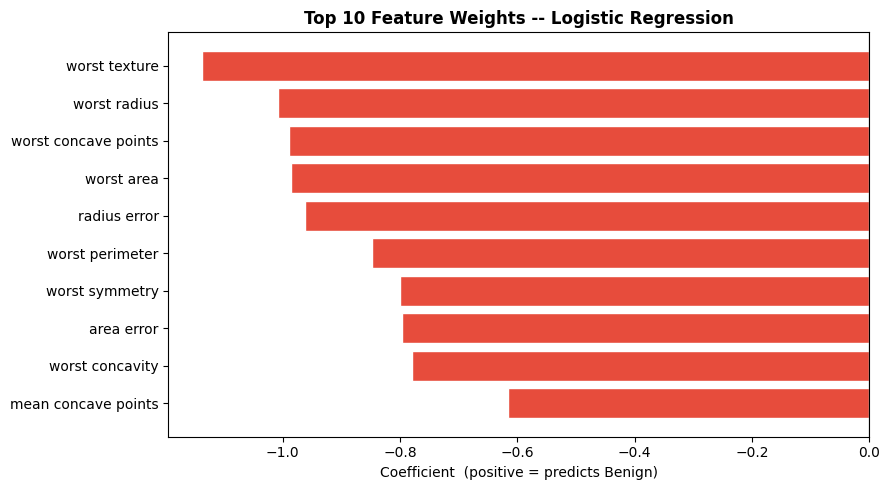

In [33]:
import pandas as pd
coeffs = pd.Series(lr_model.coef_[0], index=raw.feature_names)
top10  = coeffs.abs().sort_values(ascending=False).head(10).index
vals   = coeffs[top10]

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in vals]
plt.figure(figsize=(9, 5))
plt.barh(top10[::-1], vals[::-1], color=colors[::-1], edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 Feature Weights -- Logistic Regression', fontweight='bold')
plt.xlabel('Coefficient  (positive = predicts Benign)')
plt.tight_layout()
plt.show()

---
## 5. Neural Network with PyTorch

We will build a **Multilayer Perceptron (MLP)**:
![MLP Architecture](./images/mlp_architecture.png)

### Key PyTorch concepts
- `nn.Module`: base class for all models -- subclass it and implement `forward()`
- `DataLoader`: automatically batches and shuffles your dataset
- `loss.backward()`: computes gradients via backpropagation
- `optimizer.step()`: updates weights using those gradients
- `model.train()` / `model.eval()`: toggle dropout and batchnorm behaviour

In [34]:
class CancerClassifier(nn.Module):
    def __init__(self, input_dim=30, dropout_p=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(p=dropout_p),

            nn.Linear(32, 1),  # raw logit; sigmoid applied inside the loss
        )

    def forward(self, x):
        return self.net(x)


model = CancerClassifier(input_dim=X_train_s.shape[1])
print(model)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'\nTrainable parameters: {n_params:,}')

CancerClassifier(
  (net): Sequential(
    (0): Linear(in_features=30, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)

Trainable parameters: 4,289


In [36]:
def make_dataloader(X, y, batch_size=32, shuffle=True):
    X_t = torch.tensor(X, dtype=torch.float32)
    y_t = torch.tensor(y, dtype=torch.float32).unsqueeze(1)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE   = 32
train_loader = make_dataloader(X_train_s, y_train, shuffle=True)
val_loader   = make_dataloader(X_val_s, y_val, shuffle=False)

X_b, y_b = next(iter(train_loader)) # pops the next data batch sample
print(f'Single batch shapes -> X: {X_b.shape}  y: {y_b.shape}')

Single batch shapes -> X: torch.Size([32, 30])  y: torch.Size([32, 1])


In [37]:
DEVICE   = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
N_EPOCHS = 100
LR       = 1e-3

model     = CancerClassifier(input_dim=X_train_s.shape[1]).to(DEVICE)
criterion = nn.BCEWithLogitsLoss()   # sigmoid + BCE in one numerically stable op
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

print(f'Training on: {DEVICE}')
print(f'{"Epoch":>6}  {"Train Loss":>10}  {"Val Loss":>10}  {"Train Acc":>10}  {"Val Acc":>10}')
print('-' * 58)

for epoch in range(1, N_EPOCHS + 1):

    # Training phase
    model.train()
    t_loss, t_correct, t_total = 0.0, 0, 0
    for X_b, y_b in train_loader:
        X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
        optimizer.zero_grad()             # clear old gradients
        logits = model(X_b)               # forward pass
        loss   = criterion(logits, y_b)   # compute loss
        loss.backward()                   # backprop: compute gradients
        optimizer.step()                  # gradient descent step
        t_loss    += loss.item() * X_b.size(0)
        preds      = (torch.sigmoid(logits) >= 0.5).float()
        t_correct += (preds == y_b).sum().item()
        t_total   += X_b.size(0)
    train_loss = t_loss / t_total
    train_acc  = t_correct / t_total

    # Validation phase
    model.eval()
    v_loss, v_correct, v_total = 0.0, 0, 0
    with torch.no_grad():                 # no gradient computation needed
        for X_b, y_b in val_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            logits = model(X_b)
            v_loss    += criterion(logits, y_b).item() * X_b.size(0)
            preds      = (torch.sigmoid(logits) >= 0.5).float()
            v_correct += (preds == y_b).sum().item()
            v_total   += X_b.size(0)
    val_loss = v_loss / v_total
    val_acc  = v_correct / v_total

    scheduler.step(val_loss)
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if epoch % 10 == 0 or epoch == 1:
        print(f'{epoch:>6}  {train_loss:>10.4f}  {val_loss:>10.4f}  '
              f'{train_acc*100:>9.2f}%  {val_acc*100:>9.2f}%')

print('\nTraining complete!')

Training on: cuda
 Epoch  Train Loss    Val Loss   Train Acc     Val Acc
----------------------------------------------------------
     1      0.6610      0.6033      54.95%      80.22%
    10      0.2215      0.2101      96.98%      98.90%
    20      0.1097      0.1114      98.08%      98.90%
    30      0.0760      0.0847      98.63%      98.90%
    40      0.0691      0.0712      97.53%      98.90%
    50      0.0505      0.0775      98.63%      97.80%
    60      0.0519      0.0706      98.63%      97.80%
    70      0.0633      0.0707      97.80%      97.80%
    80      0.0661      0.0704      97.80%      97.80%
    90      0.0573      0.0709      98.08%      97.80%
   100      0.0490      0.0712      98.63%      97.80%

Training complete!


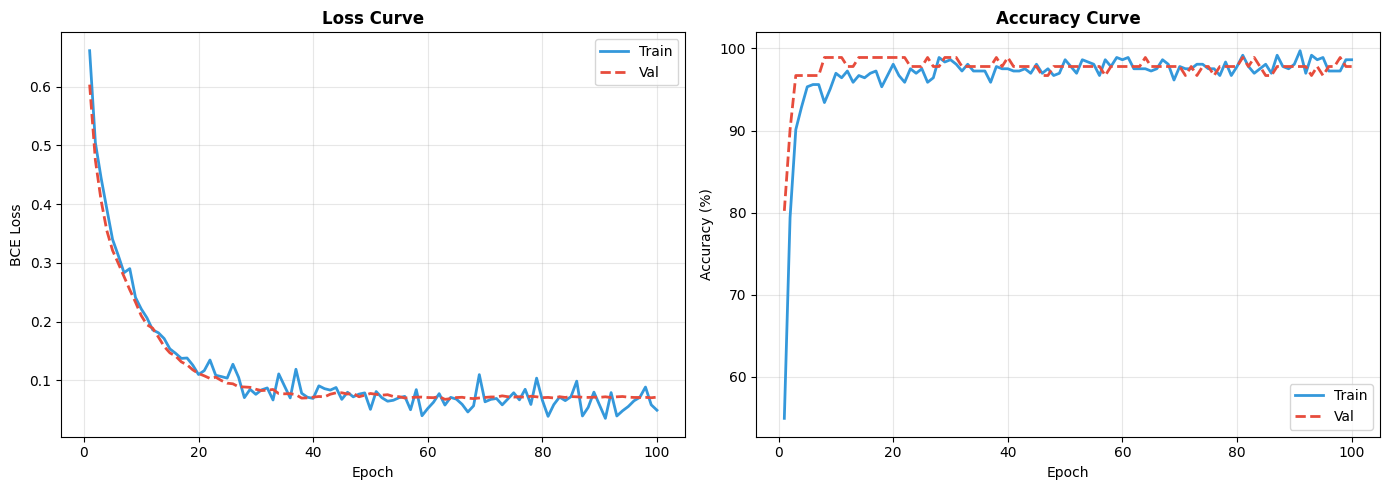

If train loss falls but val loss rises --> overfitting. Both should trend down together.


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
epochs = range(1, N_EPOCHS + 1)

axes[0].plot(epochs, history['train_loss'], label='Train', color='#3498db', lw=2)
axes[0].plot(epochs, history['val_loss'],   label='Val',   color='#e74c3c', lw=2, ls='--')
axes[0].set_title('Loss Curve', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('BCE Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [a*100 for a in history['train_acc']], label='Train', color='#3498db', lw=2)
axes[1].plot(epochs, [a*100 for a in history['val_acc']],   label='Val',   color='#e74c3c', lw=2, ls='--')
axes[1].set_title('Accuracy Curve', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy (%)')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print('If train loss falls but val loss rises --> overfitting. Both should trend down together.')

---
## 6. Evaluate and Visualise Results

Now we open the envelope -- both models are run on the **held-out test set**.

In [39]:
model.eval()
X_test_t = torch.tensor(X_test_s, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    nn_probs = torch.sigmoid(model(X_test_t)).cpu().numpy().squeeze()
nn_preds = (nn_probs >= 0.5).astype(float)

nn_acc, nn_auc = evaluate('PyTorch MLP', y_test, nn_preds, nn_probs)

print('\nSummary:')
print(f'  Logistic Regression -- Acc: {lr_acc*100:.2f}%  AUC: {lr_auc:.4f}')
print(f'  PyTorch MLP         -- Acc: {nn_acc*100:.2f}%  AUC: {nn_auc:.4f}')


  PyTorch MLP
  Accuracy : 96.49%
  ROC-AUC  : 0.9967
Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.95      0.95        42
      Benign       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114


Summary:
  Logistic Regression -- Acc: 98.25%  AUC: 0.9957
  PyTorch MLP         -- Acc: 96.49%  AUC: 0.9967


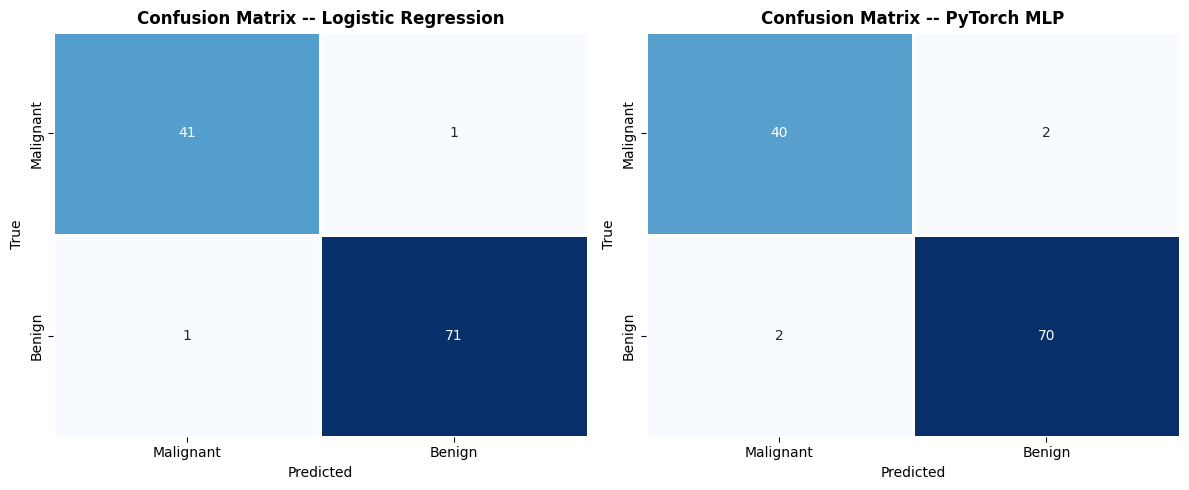

In medicine, false negatives (missed malignancies) are often more costly than false positives.
Lowering the decision threshold (e.g. 0.3) increases sensitivity at the cost of more false positives.


In [40]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, preds, title in [
    (axes[0], lr_preds, 'Logistic Regression'),
    (axes[1], nn_preds, 'PyTorch MLP'),
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Malignant', 'Benign'],
                yticklabels=['Malignant', 'Benign'],
                linewidths=1, cbar=False)
    ax.set_title(f'Confusion Matrix -- {title}', fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')

plt.tight_layout()
plt.show()
print('In medicine, false negatives (missed malignancies) are often more costly than false positives.')
print('Lowering the decision threshold (e.g. 0.3) increases sensitivity at the cost of more false positives.')

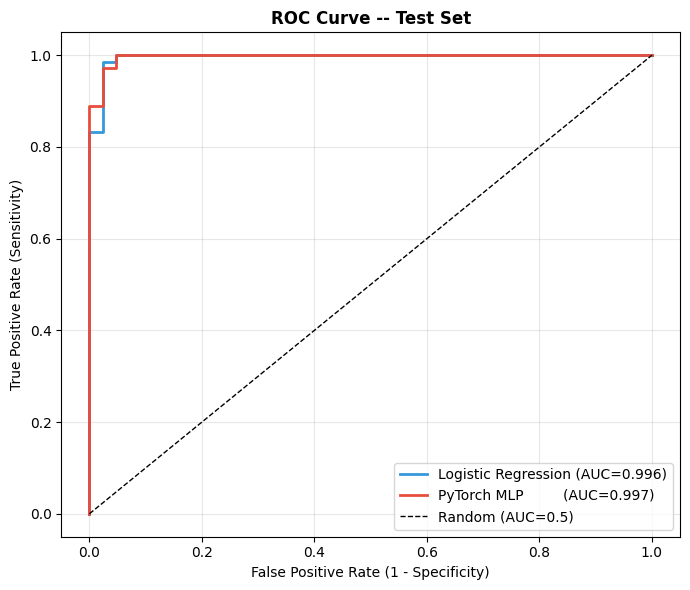

AUC = 1.0 is perfect. AUC = 0.5 is random guessing.
AUC is threshold-independent -- it measures overall discriminative power.


In [41]:
plt.figure(figsize=(7, 6))
for probs, label, color in [
    (lr_probs, f'Logistic Regression (AUC={lr_auc:.3f})', '#3498db'),
    (nn_probs, f'PyTorch MLP         (AUC={nn_auc:.3f})', '#e74c3c'),
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    plt.plot(fpr, tpr, label=label, lw=2, color=color)

plt.plot([0,1],[0,1],'k--', lw=1, label='Random (AUC=0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('ROC Curve -- Test Set', fontweight='bold')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('AUC = 1.0 is perfect. AUC = 0.5 is random guessing.')
print('AUC is threshold-independent -- it measures overall discriminative power.')

---
## 7. Bonus: Demonstrating Overfitting

Let's deliberately overfit a model to illustrate the concept visually.
No dropout, no weight decay, an oversized network, many epochs.

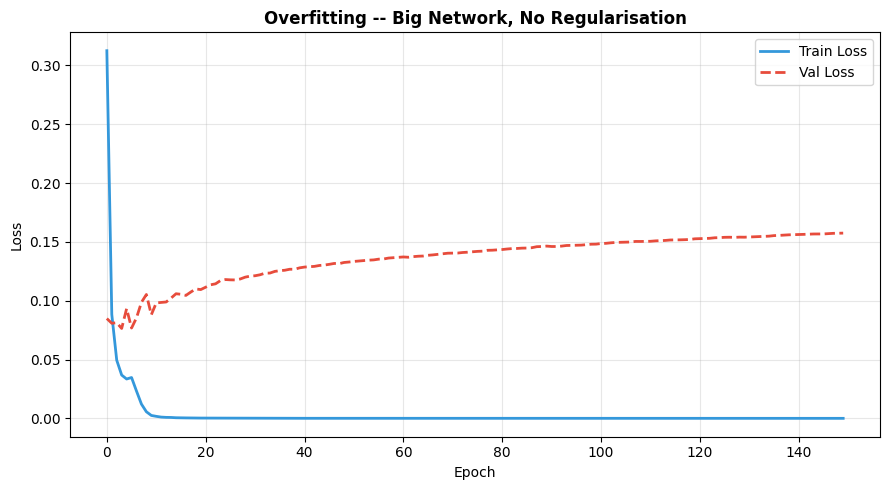

Train loss --> 0, but val loss rises. The model is memorising the training data.
Fixes: Dropout, weight decay (L2 reg), early stopping, more data, simpler model.


In [42]:
class BigNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(),
            nn.Linear(512, 512),       nn.ReLU(),
            nn.Linear(512, 256),       nn.ReLU(),
            nn.Linear(256, 1),
        )
    def forward(self, x): return self.net(x)


def quick_train(model, n_epochs=150):
    crit = nn.BCEWithLogitsLoss()
    opt  = optim.Adam(model.parameters(), lr=1e-3)  # no weight_decay!
    hist = {'train': [], 'val': []}
    for _ in range(n_epochs):
        model.train()
        losses = []
        for X_b, y_b in train_loader:
            X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(X_b), y_b)
            loss.backward(); opt.step()
            losses.append(loss.item())
        hist['train'].append(np.mean(losses))
        model.eval()
        vlosses = []
        with torch.no_grad():
            for X_b, y_b in val_loader:
                X_b, y_b = X_b.to(DEVICE), y_b.to(DEVICE)
                vlosses.append(crit(model(X_b), y_b).item())
        hist['val'].append(np.mean(vlosses))
    return hist


overfit_model = BigNet(X_train_s.shape[1]).to(DEVICE)
overfit_hist  = quick_train(overfit_model, n_epochs=150)

plt.figure(figsize=(9, 5))
plt.plot(overfit_hist['train'], label='Train Loss', color='#3498db', lw=2)
plt.plot(overfit_hist['val'],   label='Val Loss',   color='#e74c3c', lw=2, ls='--')
plt.title('Overfitting -- Big Network, No Regularisation', fontweight='bold')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
print('Train loss --> 0, but val loss rises. The model is memorising the training data.')
print('Fixes: Dropout, weight decay (L2 reg), early stopping, more data, simpler model.')